# periscope_drift

using JC's script


In [1]:
#source /export/CIAOT/ciaot_install/20180306/ciao-4.10/bin/ciao.bash -o
#ciaover -v
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./

The current environment is configured for:
  CIAO        : CIAO 4.11 Wednesday, December  5, 2018
  Tools       : Package release 1  Wednesday, December 5, 2018
  Sherpa      : Package release 1  Wednesday, December 5, 2018
  Chips       : Package release 1  Wednesday, December 5, 2018
  Prism       : Package release 1  Wednesday, December 5, 2018
  Obsvis      : Package release 1  Wednesday, December 5, 2018
  Core        : Package release 1  Wednesday, December 5, 2018
  Graphics    : Package release 1  Tuesday, November 13, 2018
  Contrib     : Package release 1  Friday, November 30, 2018
  bindir      : /export/CIAOT/ciaot_install/20181205/ciao-4.11/bin
  Python path : /export/CIAOT/ciaot_install/20181205/ciao-4.11/ots/bin
  CALDB       : 4.8.1

CIAO Installation: Linux
System information:
Linux lenin 2.6.32-754.9.1.el6.x86_64 #1 SMP Thu Dec 6 08:02:15 UTC 2018 x86_64 x86_64 x86_64 GNU/Linux


## download

In [2]:
download_chandra_obsid 17128 asol,evt2,evt1,bpix,msk,flt,stat,fov,mtl,dtf,bias,pbk


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  evt2     fits       40 Mb  ####################          < 1 s  78796.6 kb/s
  asol     fits       30 Mb  ####################          < 1 s  69784.2 kb/s
  bpix     fits       57 Kb  ####################          < 1 s  5472.6 kb/s
  fov      fits        5 Kb  ####################          < 1 s  762.4 kb/s
  stat     fits        4 Mb  ####################          < 1 s  48486.0 kb/s
  flt      fits        6 Kb  ####################          < 1 s  886.1 kb/s
  msk      fits        5 Kb  ####################          < 1 s  697.6 kb/s
  mtl      fits        5 Mb  ####################          < 1 s  55714.6 kb/s
  evt1     fits      284 Mb  ####################            5 s  55546.9 kb/s
  bias     fits      496 Kb  ####################          < 1 s  23043.9 kb/s
  bias     fits      462 Kb  ####################          <

## Run celldetect

In [3]:
celldetect infile= 17128/primary/acisf17128N003_evt2.fits.gz outfile=mysrc.fits clob+ fixed=12


In [4]:
mkpsfmap 17128/primary/acisf17128N003_evt2.fits.gz  my.psfmap energy=1.4967 ecf=0.8 spectrum= clob+

In [5]:
celldetect infile= 17128/primary/acisf17128N003_evt2.fits.gz outfile=mysrc_psfmap.fits clob+ \
  fixed=0 psffile=my.psfmap max=8192 

In [6]:
dmsort mysrc.fits"[SRCLIST]" key=-snr outfile=mysrc_snrsort.fits clob+

In [7]:
dmlist mysrc_snrsort.fits"[cols net_counts,x,y,snr,r][net_counts=500:]" data  | head

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    NET_COUNTS           POS(X,Y)                                 SNR                  R[2]
 
     1               6025.0      (     4064.822080,     4071.903520)        73.3563461304 [        3.5802631378         2.9642162323]


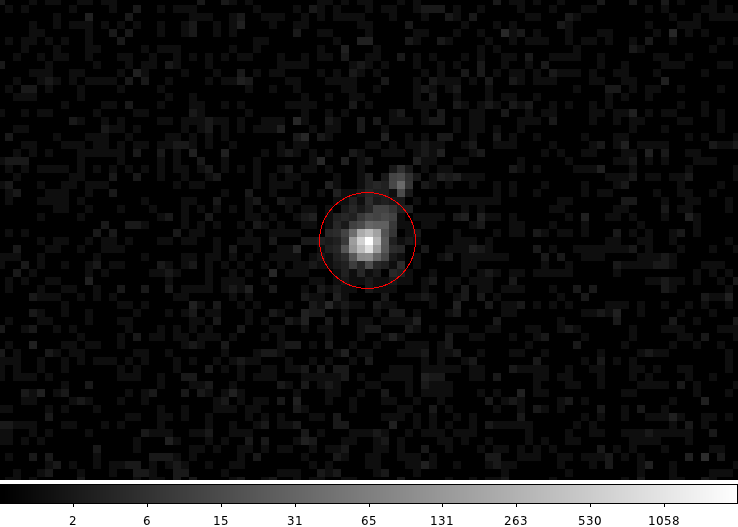

In [8]:
ds9 17128/primary/acisf17128N003_evt2.fits.gz \
 -bin about 4064.822080 4071.903520 \
 -scale log \
 -regions command "circle 4064.822080  4071.903520 6 # color=red" \
 -zoom 8 \
 -saveimage png ds9_01.png &
sleep 10
xpaset -p ds9 quit


display < ds9_01.png

## Run fix script


In [9]:
pset correct_periscope_drift x=4064.822080 y=4071.903520 radius=6

pset correct_periscope_drift infile= 17128/primary/pcadf557756838N002_asol1.fits.gz
pset correct_periscope_drift evtfile= 17128/primary/acisf17128N003_evt2.fits.gz
pset correct_periscope_drift outfile=driftcorr_asol1.fits
pset correct_periscope_drift corr_plot_root=demo_corr

correct_periscope_drift mode=h

Running: correct_periscope_drift
  version = 0.2
with parameters:
  infile=17128/primary/pcadf557756838N002_asol1.fits.gz
  evtfile=17128/primary/acisf17128N003_evt2.fits.gz
  outfile=driftcorr_asol1.fits
  verbose=2
  and ASCDS_INSTALL is /export/CIAOT/ciaot_install/20181205/ciao-4.11
------------------------------------------------------------
Fitting a line to the data to get reduced stat errors
Fitting a polynomial of degree 2 to the data
Fitting a line to the data to get reduced stat errors
Fitting a polynomial of degree 2 to the data
------------------------------------------------------------
Fit results
	Events show drift range of 0.36 arcsec in yag axis
	Max absolute correction of 0.21 arcsec for yag axis
	Events show drift range of 0.02 arcsec in zag axis
	Max absolute correction of 0.01 arcsec for zag axis
------------------------------------------------------------
Writing out corrected aspect solution file to driftcorr_asol1.fits
	To review fit see correction plots in:
		d

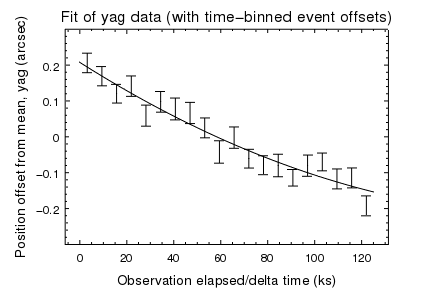

In [10]:
display < demo_corr_fit_yag.png

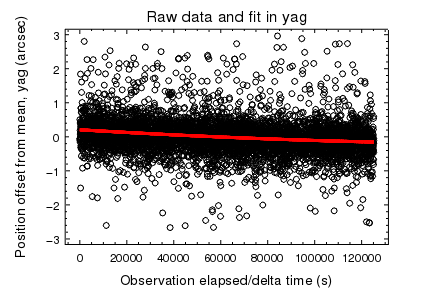

In [11]:
display < demo_corr_data_yag.png

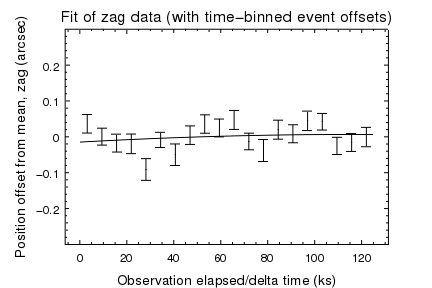

In [12]:
display < demo_corr_fit_zag.png

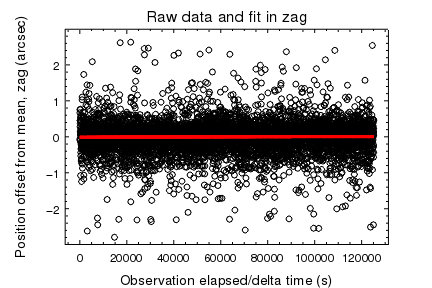

In [13]:
display < demo_corr_data_zag.png

## Apply correction : cuckoo-bird egg

In [14]:
mv -fv 17128/primary/pcadf557756838N002_asol1.fits.gz 17128/pcadf557756838N002_asol1.fits.gz.ORIG
cp -fv driftcorr_asol1.fits 17128/primary/pcadf557756838_driftcorr_asol1.fits

`17128/primary/pcadf557756838N002_asol1.fits.gz' -> `17128/pcadf557756838N002_asol1.fits.gz.ORIG'
`driftcorr_asol1.fits' -> `17128/primary/pcadf557756838_driftcorr_asol1.fits'


In [15]:
chandra_repro indir=17128 check_vf_pha=yes outdir= clob+


Processing input directory '/data/lenin2/Test/CIAO4.11/Celldetect/PeriscopeThread/17128'

Resetting afterglow status bits in evt1.fits file...

Running the destreak tool on the evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create a new bad pixel file...

Running acis_process_events to reprocess the evt1.fits file...
Output from acis_process_events:
# acis_process_events (CIAO 4.11): The following error occurred 31 times:
	dsAPEPULSEHEIGHTERR -- WARNING: pulse height is less than split threshold when performing serial CTI adjustment.
Filtering the evt1.fits file by grade and status and time...
Applying the good time intervals from the flt1.fits file...
The new evt2.fits file is: /data/lenin2/Test/CIAO4.11/Celldetect/PeriscopeThread/17128/repro/acisf17128_repro_evt2.fits

Updating the event file header with chandra_repro HISTORY record
Creating FOV file...
Setting observation-specific bad pixel file in local ardlib.par.

Cleaning up intermediate files

        

## Repeat correction

In [16]:
pset correct_periscope_drift evtfile=17128/repro/acisf17128_repro_evt2.fits
pset correct_periscope_drift infile=17128/primary/pcadf557756838_driftcorr_asol1.fits
pset correct_periscope_drift outfile=already_fixed.fits
pset correct_periscope_drift corr_plot_root="already_fixed"

correct_periscope_drift mode=h


Running: correct_periscope_drift
  version = 0.2
with parameters:
  infile=17128/primary/pcadf557756838_driftcorr_asol1.fits
  evtfile=17128/repro/acisf17128_repro_evt2.fits
  outfile=already_fixed.fits
  verbose=2
  and ASCDS_INSTALL is /export/CIAOT/ciaot_install/20181205/ciao-4.11
------------------------------------------------------------
Fitting a line to the data to get reduced stat errors
Fitting a polynomial of degree 2 to the data
Fitting a line to the data to get reduced stat errors
Fitting a polynomial of degree 2 to the data
------------------------------------------------------------
Fit results
	Events show drift range of 0.01 arcsec in yag axis
	Max absolute correction of 0.01 arcsec for yag axis
	Events show drift range of 0.01 arcsec in zag axis
	Max absolute correction of 0.00 arcsec for zag axis
------------------------------------------------------------
Writing out corrected aspect solution file to already_fixed.fits
	To review fit see correction plots in:
		alrea

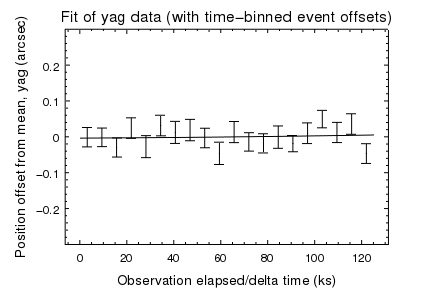

In [17]:
display < already_fixed_fit_yag.png

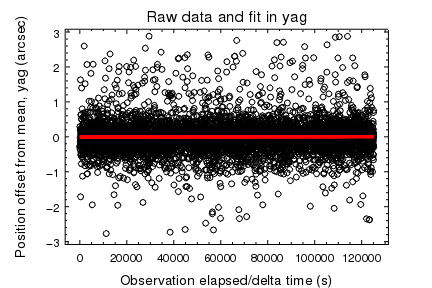

In [18]:
display < already_fixed_data_yag.png

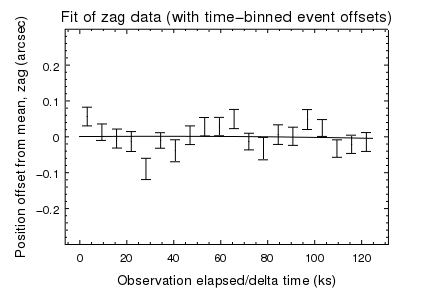

In [19]:
display < already_fixed_fit_zag.png

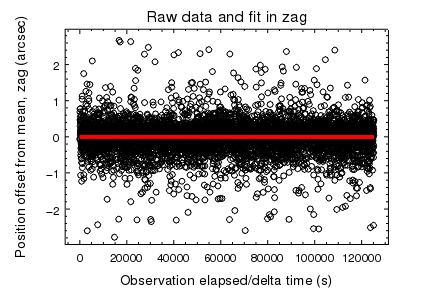

In [20]:
display < already_fixed_data_zag.png

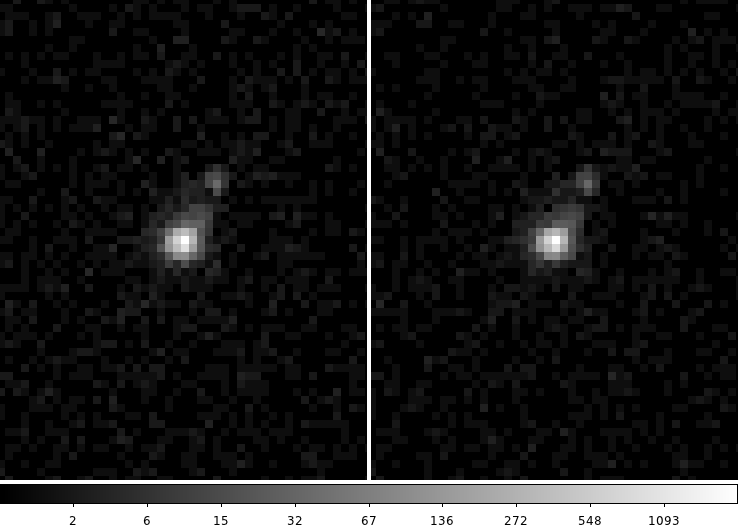

In [21]:
ds9 17128/primary/acisf17128N003_evt2.fits.gz  -scale log -zoom 8 -pan to 4064.822080 4071.903520 physical \
    17128/repro/acisf17128_repro_evt2.fits -scale log -pan to 4064.822080 4071.903520 physical \
    -saveimage png ds9_02.png &
sleep 10
xpaset -p ds9 quit


display < ds9_02.png

In [22]:
dmstat 17128/primary/acisf17128N003_evt2.fits.gz"[sky=circle(4064.822080,4071.903520,6)][energy=500:7000][cols sky]" cen+ sig+ med-
dmstat 17128/repro/acisf17128_repro_evt2.fits"[sky=circle(4064.822080,4071.903520,6)][energy=500:7000][cols sky]" cen+ sig+ med-


sky(x, y)[pixel]
    min:	( 4059.1242676 4066.2668457 )	      @:	( 715 2511 )
    max:	( 4070.3671875 4077.8151855 )	      @:	( 1057 3980 )
   mean:	( 4064.8222163 4071.8536848 )
  sigma:	( 0.921679973 0.96914840006 )
    sum:	( 24258858.987 24300822.791 )
   good:	( 5968 5968 )
   null:	( 0 0 )

sky(x, y)[pixel]
    min:	( 4059.0695801 4066.2382812 )	      @:	( 685 2420 )
    max:	( 4070.6791992 4077.7478027 )	      @:	( 786 5225 )
   mean:	( 4064.8202117 4071.8529317 )
  sigma:	( 0.91571318519 0.93157191621 )
    sum:	( 23340197.656 23380579.534 )
   good:	( 5742 5742 )
   null:	( 0 0 )



In [23]:
dmstat 17128/primary/acisf17128N003_evt2.fits.gz"[sky=circle(4064.822080,4071.903520,6)][energy=500:7000][bin sky=0.1]" cen+ sig+ med-
dmstat 17128/repro/acisf17128_repro_evt2.fits"[sky=circle(4064.822080,4071.903520,6)][energy=500:7000][bin sky=0.1]" cen+ sig+ med-


EVENTS_IMAGE(x, y)
    min:	0 	      @:	( 4064.07208 4065.95352 )
    max:	43 	      @:	( 4065.07208 4071.75352 )
cntrd[log] :	( 60.500418971 59.994972348 )
cntrd[phys]:	( 4064.8221219 4071.8530172 )
sigma_cntrd:	( 44.084399307 43.772635424 )
   good:	11304 
   null:	3096 
EVENTS_IMAGE(x, y)
    min:	0 	      @:	( 4064.07208 4065.95352 )
    max:	47 	      @:	( 4064.97208 4071.75352 )
cntrd[log] :	( 60.482061999 59.992163009 )
cntrd[phys]:	( 4064.8202862 4071.8527363 )
sigma_cntrd:	( 43.239433128 42.91272714 )
   good:	11304 
   null:	3096 
